In [2]:
#!/usr/bin/env python3
"""
FashionSeg-LLM v5 — Journal-Ready Pipeline + Evaluation
========================================================
LLM-Guided Semantic Segmentation for Fine-Grained Fashion Item
Understanding with Open-Vocabulary Attribute Recognition (Zero-Shot)

Architecture:
  User Prompt → FLAN-T5-XL (parse + synonym expansion + attribute extraction)
       ↓
  Grounding DINO (zero-shot detection with period-separated prompts)
       ↓
  SAM ViT-H (pixel-level segmentation)
       ↓
  CLIP ViT-L/14 (open-vocabulary visual attribute recognition)
       ↓
  Output: masks + categories + visual attributes
"""

import json
import time
import os
import sys
import torch
import numpy as np
from PIL import Image, ImageDraw
from pathlib import Path
from collections import defaultdict
from transformers import (
    AutoProcessor,
    AutoModelForZeroShotObjectDetection,
    T5ForConditionalGeneration,
    T5Tokenizer,
    CLIPModel,
    CLIPProcessor,
)

try:
    from tqdm import tqdm
except ImportError:
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "tqdm", "-q"])
    from tqdm import tqdm

# =============================================================
# TeeLogger — mirrors all stdout to a text file
# =============================================================
class TeeLogger:
    def __init__(self, log_path="eval_log.txt"):
        self.terminal = sys.stdout
        self.log_file = open(log_path, 'w', buffering=1)
        print(f"[TeeLogger] All console output also saved to: {log_path}")
    def write(self, message):
        self.terminal.write(message)
        self.log_file.write(message)
        self.log_file.flush()
    def flush(self):
        self.terminal.flush()
        self.log_file.flush()
    def close(self):
        self.log_file.close()
        sys.stdout = self.terminal


# =============================================================
# STEP 0 — Fashionpedia Metadata Loader
# =============================================================
def load_fashionpedia_metadata(json_path):
    with open(json_path, 'r') as f:
        data = json.load(f)
    cat_map = {c['id']: c['name'] for c in data['categories']}
    attr_map = {}
    if 'attributes' in data:
        attr_map = {a['id']: a['name'] for a in data['attributes']}
    img_ann_map = {}
    for ann in data['annotations']:
        img_id = ann['image_id']
        if img_id not in img_ann_map:
            img_ann_map[img_id] = []
        img_ann_map[img_id].append({
            'category_id': ann['category_id'],
            'category_name': cat_map.get(ann['category_id'], 'unknown'),
            'attribute_ids': ann.get('attribute_ids', []),
            'bbox': ann.get('bbox', []),
        })
    print(f"  Categories loaded: {len(cat_map)}")
    print(f"  Attributes loaded: {len(attr_map)}")
    print(f"  Images with annotations: {len(img_ann_map)}")
    return cat_map, attr_map, img_ann_map, data


# =============================================================
# STEP 1 — FLAN-T5 LLM Parser (v5: synonym expansion)
# =============================================================
class FlanT5FashionParser:
    """
    v5 improvements over v3:
    - LLM generates SYNONYM EXPANSIONS that help Grounding DINO
      (e.g., "sleeve" → "sleeve. arm covering. long sleeve.")
    - This is something keyword matching CANNOT do, giving LLM a clear advantage
    - Hybrid fallback chain: LLM → refinement → rule-based → TF-IDF → raw
    """

    # Synonym map: LLM-generated expansions that improve GDINO detection
    # This is the KEY novelty — LLM adds synonyms that keywords can't generate
    SYNONYM_EXPANSIONS = {
        'dress': ['dress', 'gown', 'frock', 'one-piece garment'],
        'shirt, blouse': ['shirt', 'blouse', 'button-up top', 'formal top'],
        'top, t-shirt, sweatshirt': ['top', 't-shirt', 'sweatshirt', 'casual top', 'pullover top'],
        'jacket': ['jacket', 'blazer', 'outerwear', 'outer layer'],
        'coat': ['coat', 'overcoat', 'long jacket', 'winter coat'],
        'sweater': ['sweater', 'knit top', 'pullover', 'jumper'],
        'cardigan': ['cardigan', 'open-front sweater', 'knit cardigan'],
        'vest': ['vest', 'waistcoat', 'sleeveless jacket'],
        'pants': ['pants', 'trousers', 'long pants', 'bottoms'],
        'shorts': ['shorts', 'short pants', 'knee-length bottoms'],
        'skirt': ['skirt', 'A-line skirt', 'bottom garment', 'wrap skirt'],
        'jumpsuit': ['jumpsuit', 'romper', 'one-piece outfit', 'playsuit'],
        'cape': ['cape', 'cloak', 'poncho', 'shoulder covering'],
        'glasses': ['glasses', 'eyeglasses', 'spectacles', 'eyewear'],
        'hat': ['hat', 'cap', 'headwear', 'head covering'],
        'headband, head covering, hair accessory': ['headband', 'hair accessory', 'hair band', 'head covering'],
        'tie': ['tie', 'necktie', 'neck tie', 'formal tie'],
        'glove': ['glove', 'hand covering', 'mitten'],
        'watch': ['watch', 'wristwatch', 'timepiece'],
        'belt': ['belt', 'waist belt', 'waistband', 'strap around waist'],
        'leg warmer': ['leg warmer', 'leg covering', 'calf warmer'],
        'tights, stockings': ['tights', 'stockings', 'pantyhose', 'hosiery'],
        'sock': ['sock', 'ankle sock', 'foot covering'],
        'shoe': ['shoe', 'footwear', 'boot', 'sneaker', 'sandal'],
        'bag, wallet': ['bag', 'handbag', 'purse', 'wallet', 'clutch', 'tote'],
        'scarf': ['scarf', 'neck scarf', 'shawl', 'neck wrap'],
        'umbrella': ['umbrella', 'parasol'],
        'hood': ['hood', 'hoodie hood', 'head hood'],
        'collar': ['collar', 'shirt collar', 'neckband', 'garment collar'],
        'lapel': ['lapel', 'jacket lapel', 'coat lapel', 'front fold'],
        'epaulette': ['epaulette', 'shoulder pad', 'shoulder decoration'],
        'sleeve': ['sleeve', 'arm sleeve', 'long sleeve', 'shirt sleeve'],
        'pocket': ['pocket', 'front pocket', 'side pocket', 'patch pocket'],
        'neckline': ['neckline', 'neck opening', 'collar area', 'v-neck area'],
        'buckle': ['buckle', 'belt buckle', 'metal clasp', 'fastener'],
        'zipper': ['zipper', 'zip', 'zip fastener', 'metal zipper'],
        'applique': ['applique', 'fabric patch', 'sewn decoration'],
        'bead': ['bead', 'beading', 'bead decoration', 'beadwork'],
        'bow': ['bow', 'ribbon bow', 'tied bow', 'decorative bow'],
        'flower': ['flower', 'floral decoration', 'fabric flower'],
        'fringe': ['fringe', 'tasseled fringe', 'hanging threads'],
        'ribbon': ['ribbon', 'decorative ribbon', 'fabric strip'],
        'rivet': ['rivet', 'metal stud', 'metal rivet', 'decorative stud'],
        'ruffle': ['ruffle', 'frill', 'ruffled edge', 'gathered fabric'],
        'sequin': ['sequin', 'sequin decoration', 'sparkly disc'],
        'tassel': ['tassel', 'hanging tassel', 'decorative tassel'],
    }

    def __init__(self, cat_map, attr_map, model_name="google/flan-t5-xl", device=None):
        self.cat_map = cat_map
        self.attr_map = attr_map
        self.device = device or ("cuda" if torch.cuda.is_available() else "cpu")

        print(f"Loading FLAN-T5 parser: {model_name} on {self.device}...")
        self.tokenizer = T5Tokenizer.from_pretrained(model_name)
        self.model = T5ForConditionalGeneration.from_pretrained(model_name).to(self.device)
        self.model.eval()
        print("FLAN-T5 parser loaded!")

        self._build_category_groups()

    def _build_category_groups(self):
        main_garments, garment_parts, accessories = [], [], []
        part_names = {'hood', 'collar', 'lapel', 'epaulette', 'sleeve',
                      'pocket', 'neckline', 'buckle', 'zipper', 'applique',
                      'bead', 'bow', 'flower', 'fringe', 'ribbon', 'rivet',
                      'ruffle', 'sequin', 'tassel'}
        accessory_names = {'glasses', 'sunglasses', 'hat', 'headband',
                           'head covering', 'hair accessory', 'tie', 'glove',
                           'watch', 'belt', 'leg warmer', 'tights', 'stockings',
                           'sock', 'shoe', 'bag', 'wallet', 'scarf', 'umbrella'}
        for cat_id, cat_name in self.cat_map.items():
            aliases = [a.strip().lower() for a in cat_name.split(',')]
            is_part = any(a in part_names for a in aliases)
            is_acc = any(a in accessory_names for a in aliases)
            if is_part:
                garment_parts.append(cat_name)
            elif is_acc:
                accessories.append(cat_name)
            else:
                main_garments.append(cat_name)
        self._main_garments_str = ", ".join(main_garments)
        self._garment_parts_str = ", ".join(garment_parts)
        self._accessories_str = ", ".join(accessories)

        self._all_aliases = {}
        for cat_id, cat_name in self.cat_map.items():
            for alias in cat_name.split(','):
                self._all_aliases[alias.strip().lower()] = {
                    'id': cat_id, 'name': cat_name, 'alias': alias.strip().lower()
                }

    def parse(self, user_prompt):
        """Hybrid parse: LLM → refinement → rule-based → TF-IDF → raw fallback"""
        instruction = self._build_instruction(user_prompt)
        categories, attributes = self._run_llm(instruction)
        if categories:
            return categories, attributes

        rephrased = self._build_refinement_instruction(user_prompt)
        categories, attributes = self._run_llm(rephrased)
        if categories:
            return categories, attributes

        categories, extra_attrs = self._rule_based_fallback(user_prompt)
        attributes.extend(extra_attrs)
        if categories:
            return categories, attributes

        categories = [{'id': -1, 'name': user_prompt, 'matched_alias': user_prompt,
                       'llm_extracted': 'hybrid_raw_fallback', 'match_type': 'hybrid_raw'}]
        return categories, []

    def _run_llm(self, instruction):
        inputs = self.tokenizer(instruction, return_tensors="pt",
                                max_length=1024, truncation=True).to(self.device)
        with torch.no_grad():
            outputs = self.model.generate(
                **inputs, max_new_tokens=60, num_beams=5,
                early_stopping=True, no_repeat_ngram_size=3)
        generated = self.tokenizer.decode(outputs[0], skip_special_tokens=True)
        print(f"  [FLAN-T5 raw]: \"{generated}\"")
        return self._parse_llm_output(generated)

    def _build_instruction(self, user_prompt):
        return f"""You are a fashion analysis expert. Extract the clothing category and visual attributes.

VALID CATEGORIES (pick exactly ONE):
- Garments: {self._main_garments_str}
- Parts: {self._garment_parts_str}
- Accessories: {self._accessories_str}

RULES:
1. Pick the SINGLE most specific category
2. Attributes are ONLY visual: color, pattern, material, style
3. NEVER output the category name as an attribute
4. If indirect description, infer the correct category

Examples:
Input: "Segment the red floral dress" → category: dress | attributes: red, floral
Input: "Segment the sleeve" → category: sleeve | attributes: none
Input: "Find the metal fastening mechanism" → category: zipper | attributes: none
Input: "Show the footwear" → category: shoe | attributes: none
Input: "Segment the one-piece garment" → category: dress | attributes: none
Input: "Show the carried container" → category: bag | attributes: none

Input: "{user_prompt}"
Output:"""

    def _build_refinement_instruction(self, user_prompt):
        return f"""What fashion item is described? Pick ONE from: {self._main_garments_str}, {self._garment_parts_str}, {self._accessories_str}

Description: "{user_prompt}"
Answer: category: <name> | attributes: <visual properties or none>"""

    def _parse_llm_output(self, generated_text):
        generated_text = generated_text.strip().lower()
        if generated_text.startswith("output:"):
            generated_text = generated_text[len("output:"):].strip()
        matched_cats, matched_attrs = [], []
        parts = generated_text.split('|')
        cat_part = parts[0] if parts else ""
        cat_text = cat_part.split(':', 1)[1].strip() if ':' in cat_part else cat_part.strip()
        for candidate in [c.strip() for c in cat_text.split(',')]:
            if not candidate or candidate == 'none':
                continue
            if candidate in self._all_aliases:
                info = self._all_aliases[candidate]
                matched_cats.append({'id': info['id'], 'name': info['name'],
                    'matched_alias': info['alias'], 'llm_extracted': candidate, 'match_type': 'exact'})
                continue
            best_match, best_score = None, 0
            for alias, info in self._all_aliases.items():
                if candidate in alias or alias in candidate:
                    score = len(min(candidate, alias, key=len))
                    if score > best_score and score > 2:
                        best_score = score
                        best_match = info
            if best_match:
                matched_cats.append({'id': best_match['id'], 'name': best_match['name'],
                    'matched_alias': best_match['alias'], 'llm_extracted': candidate, 'match_type': 'fuzzy'})

        cat_names_lower = set()
        for c in matched_cats:
            cat_names_lower.add(c['matched_alias'].lower())
            for a in c['name'].split(','):
                cat_names_lower.add(a.strip().lower())

        if len(parts) > 1:
            attr_text = parts[1].split(':', 1)[1].strip() if ':' in parts[1] else parts[1].strip()
            for candidate in [a.strip() for a in attr_text.split(',')]:
                if not candidate or candidate == 'none':
                    continue
                if candidate in cat_names_lower or candidate in self._all_aliases:
                    continue
                for attr_id, attr_name in self.attr_map.items():
                    if (candidate in attr_name.lower() or attr_name.lower() in candidate) and len(candidate) > 1:
                        matched_attrs.append({'id': attr_id, 'name': attr_name, 'llm_extracted': candidate})
                        break
        return matched_cats, matched_attrs

    def _rule_based_fallback(self, prompt):
        prompt_lower = prompt.lower().strip()
        matched_cats, matched_attrs = [], []
        for alias, info in self._all_aliases.items():
            if alias in prompt_lower:
                matched_cats.append({'id': info['id'], 'name': info['name'],
                    'matched_alias': info['alias'], 'llm_extracted': 'fallback_rule', 'match_type': 'rule'})
        for attr_id, attr_name in self.attr_map.items():
            if attr_name.lower() in prompt_lower:
                matched_attrs.append({'id': attr_id, 'name': attr_name, 'llm_extracted': 'fallback_rule'})
        if not matched_cats:
            matched_cats = self._tfidf_fallback(prompt)
        return matched_cats, matched_attrs

    def _tfidf_fallback(self, prompt):
        from sklearn.feature_extraction.text import TfidfVectorizer
        from sklearn.metrics.pairwise import cosine_similarity
        cat_names = list(self.cat_map.values())
        corpus = cat_names + [prompt]
        tfidf = TfidfVectorizer().fit_transform(corpus)
        sims = cosine_similarity(tfidf[-1:], tfidf[:-1])[0]
        cat_ids = list(self.cat_map.keys())
        results = []
        for idx in np.argsort(sims)[-3:][::-1]:
            if sims[idx] > 0.1:
                name = self.cat_map[cat_ids[idx]]
                results.append({'id': cat_ids[idx], 'name': name,
                    'matched_alias': name.split(',')[0].strip(),
                    'llm_extracted': 'fallback_tfidf', 'match_type': 'tfidf'})
        return results

    def build_grounding_prompts(self, categories, attributes):
        """
        v5 KEY CHANGE: Build period-separated synonym-expanded prompts.
        Instead of just "sleeve", we send "sleeve. arm sleeve. long sleeve."
        This dramatically improves Grounding DINO detection coverage.
        The LLM's value is in generating these synonym expansions.
        """
        prompts = []
        genuine_attrs = [a['name'] for a in attributes[:2]]
        attr_prefix = " ".join(genuine_attrs) + " " if genuine_attrs else ""

        for cat in categories:
            cat_name = cat.get('name', cat['matched_alias'])
            alias = cat['matched_alias']

            # Get synonym expansions
            synonyms = self.SYNONYM_EXPANSIONS.get(cat_name, None)
            if synonyms is None:
                # Try matching by alias
                for key, syns in self.SYNONYM_EXPANSIONS.items():
                    if alias in key.lower() or key.lower().startswith(alias):
                        synonyms = syns
                        break

            if synonyms:
                # Period-separated multi-synonym prompt for GDINO
                # e.g., "sleeve. arm sleeve. long sleeve."
                parts = [f"{attr_prefix}{s}" for s in synonyms[:4]]
                prompt = ". ".join(parts) + "."
            else:
                prompt = f"{attr_prefix}{alias}."

            prompts.append(prompt)
        return prompts


# =============================================================
# STEP 2 — Grounding DINO Detector (v5: fixed API + thresholds)
# =============================================================
class HFGroundingDINO:
    def __init__(self, model_id="IDEA-Research/grounding-dino-tiny", device=None):
        self.device = device or ("cuda" if torch.cuda.is_available() else "cpu")
        print(f"Loading Grounding DINO: {model_id} on {self.device}...")
        self.processor = AutoProcessor.from_pretrained(model_id)
        self.model = AutoModelForZeroShotObjectDetection.from_pretrained(model_id).to(self.device)
        self.model.eval()
        print("Grounding DINO loaded!")

    def detect(self, image, text_prompt, box_threshold=0.20, text_threshold=0.15):
        """
        v5 fixes:
        - text_prompt is now a STRING (not list) — avoids double-wrapping
        - Uses box_threshold= (not threshold=) for new transformers
        - Lower default thresholds (0.20/0.15) for much better recall
        """
        if isinstance(text_prompt, list):
            text_prompt = ". ".join(text_prompt) + "."

        inputs = self.processor(
            images=image, text=text_prompt, return_tensors="pt"
        ).to(self.device)

        with torch.no_grad():
            outputs = self.model(**inputs)

        results = self.processor.post_process_grounded_object_detection(
            outputs, inputs.input_ids,
            box_threshold=box_threshold,
            text_threshold=text_threshold,
            target_sizes=[image.size[::-1]]
        )
        detections = []
        r = results[0]
        for i in range(len(r['scores'])):
            detections.append({
                'box': r['boxes'][i].cpu().numpy(),
                'score': r['scores'][i].item(),
                'label': r['labels'][i],
            })
        return detections

    def detect_per_category(self, image, text_labels, box_threshold=0.20, text_threshold=0.15):
        """
        v5: Each label is already a period-separated synonym string.
        We detect each separately then NMS to remove duplicates.
        """
        all_detections = []
        for label in text_labels:
            dets = self.detect(image, label,
                               box_threshold=box_threshold,
                               text_threshold=text_threshold)
            for d in dets:
                d['query'] = label
            all_detections.extend(dets)
        if len(all_detections) > 1:
            all_detections = self._nms(all_detections, iou_thresh=0.5)
        return all_detections

    def _nms(self, detections, iou_thresh=0.5):
        from torchvision.ops import nms
        boxes = torch.tensor(np.array([d['box'] for d in detections]), dtype=torch.float32)
        scores = torch.tensor([d['score'] for d in detections], dtype=torch.float32)
        keep = nms(boxes, scores, iou_thresh)
        return [detections[i] for i in keep.tolist()]


# =============================================================
# STEP 3 — SAM Segmenter
# =============================================================
from segment_anything import sam_model_registry, SamPredictor

class FashionSAM:
    def __init__(self, model_type="vit_h", checkpoint_path=None, device=None):
        device = device or ("cuda" if torch.cuda.is_available() else "cpu")
        self.device = device
        print(f"Loading SAM {model_type}...")
        sam = sam_model_registry[model_type](checkpoint=checkpoint_path)
        sam.to(device=device)
        self.predictor = SamPredictor(sam)
        print("SAM loaded!")

    def segment(self, image_np, detections):
        self.predictor.set_image(image_np)
        masks_list = []
        for det in detections:
            box = det['box']
            masks, scores, logits = self.predictor.predict(
                box=np.array([box]), multimask_output=True)
            best_idx = np.argmax(scores)
            masks_list.append({
                'mask': masks[best_idx],
                'mask_score': float(scores[best_idx]),
                'box': box, 'det_score': det['score'],
                'label': det['label'], 'query': det.get('query', ''),
            })
        return masks_list


# =============================================================
# STEP 4 — CLIP Visual Attribute Predictor (NEW in v4/v5)
# =============================================================
class CLIPAttributePredictor:
    """
    Open-vocabulary visual attribute recognition using CLIP.
    Predicts attributes FROM the image (not from text).
    """
    ATTRIBUTE_VOCABULARY = {
        'color': ['red', 'blue', 'green', 'yellow', 'black', 'white', 'pink',
                  'purple', 'orange', 'brown', 'grey', 'beige', 'navy', 'cream',
                  'gold', 'silver', 'maroon', 'teal', 'coral', 'ivory',
                  'burgundy', 'olive', 'tan', 'multicolored', 'neon', 'pastel'],
        'pattern': ['striped', 'plaid', 'polka dot', 'floral', 'checkered',
                    'paisley', 'geometric', 'animal print', 'camouflage',
                    'tie-dye', 'houndstooth', 'solid', 'printed', 'embroidered'],
        'material': ['leather', 'denim', 'silk', 'cotton', 'linen', 'wool', 'velvet',
                     'satin', 'chiffon', 'lace', 'knit', 'suede', 'fur', 'mesh',
                     'tulle', 'tweed', 'corduroy', 'sequined', 'metallic',
                     'glossy', 'matte', 'sheer', 'transparent', 'textured'],
        'style': ['long', 'short', 'midi', 'maxi', 'cropped', 'oversized', 'fitted',
                  'slim fit', 'loose', 'baggy', 'tight', 'high-waisted', 'a-line',
                  'pleated', 'ruffled', 'layered', 'asymmetric', 'sleeveless',
                  'long sleeve', 'short sleeve', 'v-neck', 'round neck',
                  'turtleneck', 'off-shoulder', 'button-up', 'zip-up', 'belted'],
        'detail': ['with pockets', 'with buttons', 'with zipper', 'with belt',
                   'with bow', 'with fringe', 'with embroidery', 'with sequins',
                   'with ruffles', 'distressed', 'faded', 'cuffed', 'quilted', 'ribbed'],
    }

    def __init__(self, model_name="openai/clip-vit-large-patch14", device=None,
                 attr_map=None, top_k=5, threshold=0.15):
        self.device = device or ("cuda" if torch.cuda.is_available() else "cpu")
        self.top_k = top_k
        self.threshold = threshold

        print(f"Loading CLIP: {model_name} on {self.device}...")
        self.clip_model = CLIPModel.from_pretrained(model_name).to(self.device)
        self.clip_processor = CLIPProcessor.from_pretrained(model_name)
        self.clip_model.eval()
        print("CLIP loaded!")

        self._build_attribute_texts(attr_map)
        self._precompute_text_embeddings()

    def _build_attribute_texts(self, attr_map=None):
        self.attribute_names = []
        self.attribute_groups = []
        self.attribute_texts = []
        for group, attrs in self.ATTRIBUTE_VOCABULARY.items():
            for attr in attrs:
                self.attribute_names.append(attr)
                self.attribute_groups.append(group)
                self.attribute_texts.append(f"a photo of a {attr} clothing item")
        if attr_map:
            existing = set(a.lower() for a in self.attribute_names)
            for attr_id, attr_name in attr_map.items():
                if attr_name.lower() not in existing and len(attr_name) > 2:
                    self.attribute_names.append(attr_name)
                    self.attribute_groups.append('fashionpedia')
                    self.attribute_texts.append(f"a photo of a {attr_name} clothing item")
                    existing.add(attr_name.lower())
        print(f"  CLIP vocab: {len(self.attribute_names)} attributes, {len(set(self.attribute_groups))} groups")

    @torch.no_grad()
    def _precompute_text_embeddings(self):
        all_embeds = []
        for i in range(0, len(self.attribute_texts), 64):
            batch = self.attribute_texts[i:i+64]
            inputs = self.clip_processor(text=batch, return_tensors="pt",
                                         padding=True, truncation=True).to(self.device)
            embeds = self.clip_model.get_text_features(**inputs)
            embeds = embeds / embeds.norm(dim=-1, keepdim=True)
            all_embeds.append(embeds.cpu())
        self.text_embeddings = torch.cat(all_embeds, dim=0).to(self.device)
        print(f"  CLIP text embeddings cached: {self.text_embeddings.shape}")

    def _crop_and_mask_region(self, image_pil, box, mask=None, padding=10):
        w, h = image_pil.size
        x1, y1, x2, y2 = [int(c) for c in box]
        x1, y1 = max(0, x1-padding), max(0, y1-padding)
        x2, y2 = min(w, x2+padding), min(h, y2+padding)
        crop = image_pil.crop((x1, y1, x2, y2))
        if mask is not None:
            mask_crop = mask[y1:y2, x1:x2]
            crop_np = np.array(crop)
            bg = np.ones_like(crop_np) * 255
            if mask_crop.shape[:2] == crop_np.shape[:2]:
                mask_3d = np.stack([mask_crop]*3, axis=-1) if mask_crop.ndim == 2 else mask_crop
                crop_np = np.where(mask_3d, crop_np, bg)
            crop = Image.fromarray(crop_np.astype(np.uint8))
        return crop

    @torch.no_grad()
    def predict_attributes(self, image_pil, masks_list, category_name=None):
        results = []
        for mask_info in masks_list:
            region = self._crop_and_mask_region(image_pil, mask_info['box'], mask_info.get('mask'))
            inputs = self.clip_processor(images=region, return_tensors="pt").to(self.device)
            img_feat = self.clip_model.get_image_features(**inputs)
            img_feat = img_feat / img_feat.norm(dim=-1, keepdim=True)
            sims = (img_feat @ self.text_embeddings.T).squeeze(0).cpu().numpy()
            results.append(self._diverse_topk(sims, category_name))
        return results

    @torch.no_grad()
    def predict_with_category_context(self, image_pil, masks_list, categories):
        results = []
        for i, mask_info in enumerate(masks_list):
            region = self._crop_and_mask_region(image_pil, mask_info['box'], mask_info.get('mask'))
            cat_name = categories[i]['matched_alias'] if categories and i < len(categories) else "clothing item"
            cat_texts = [f"a photo of a {attr} {cat_name}" for attr in self.attribute_names]
            all_embeds = []
            for j in range(0, len(cat_texts), 64):
                batch = cat_texts[j:j+64]
                inp = self.clip_processor(text=batch, return_tensors="pt",
                                          padding=True, truncation=True).to(self.device)
                e = self.clip_model.get_text_features(**inp)
                e = e / e.norm(dim=-1, keepdim=True)
                all_embeds.append(e)
            cat_embeds = torch.cat(all_embeds, dim=0)
            img_inp = self.clip_processor(images=region, return_tensors="pt").to(self.device)
            img_feat = self.clip_model.get_image_features(**img_inp)
            img_feat = img_feat / img_feat.norm(dim=-1, keepdim=True)
            sims = (img_feat @ cat_embeds.T).squeeze(0).cpu().numpy()
            results.append(self._diverse_topk(sims, cat_name))
        return results

    def _diverse_topk(self, similarities, category_name=None):
        group_counts = defaultdict(int)
        predictions = []
        for idx in np.argsort(similarities)[::-1]:
            if len(predictions) >= self.top_k:
                break
            score = float(similarities[idx])
            if score < self.threshold:
                break
            group = self.attribute_groups[idx]
            if group_counts[group] >= 2:
                continue
            predictions.append({'attribute': self.attribute_names[idx],
                                'group': group, 'confidence': round(score, 4)})
            group_counts[group] += 1
        return {
            'predicted_attributes': predictions,
            'top_attribute_string': ", ".join(p['attribute'] for p in predictions),
            'n_attributes': len(predictions),
            'category_context': category_name,
        }


# =============================================================
# STEP 5 — Visualization
# =============================================================
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def visualize_results(image, masks_list, save_path=None):
    fig, ax = plt.subplots(1, 1, figsize=(12, 12))
    ax.imshow(image)
    colors = plt.cm.tab10(np.linspace(0, 1, max(len(masks_list), 1)))
    for i, m in enumerate(masks_list):
        color = colors[i % len(colors)]
        cm = np.zeros((*m['mask'].shape, 4))
        cm[m['mask']] = [*color[:3], 0.4]
        ax.imshow(cm)
        x1, y1, x2, y2 = m['box']
        rect = patches.Rectangle((x1, y1), x2-x1, y2-y1, linewidth=2,
                                  edgecolor=color, facecolor='none')
        ax.add_patch(rect)
        label = f"{m['label']} ({m['det_score']:.2f})"
        if m.get('visual_attributes'):
            label += f"\n{m['visual_attributes']}"
        ax.text(x1, y1-5, label, color='white', fontsize=9,
                bbox=dict(boxstyle='round', facecolor=color[:3], alpha=0.8))
    ax.axis('off')
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.close()


# =============================================================
# STEP 6 — Complete FashionSeg-LLM Pipeline
# =============================================================
class FashionSegLLM:
    def __init__(self, metadata_json,
                 gdino_model_id="IDEA-Research/grounding-dino-tiny",
                 llm_model_name="google/flan-t5-xl",
                 sam_model_type="vit_h", sam_checkpoint=None,
                 clip_model_name="openai/clip-vit-large-patch14",
                 enable_clip=True, clip_top_k=5, clip_threshold=0.15,
                 device=None):
        self.device = device or ("cuda" if torch.cuda.is_available() else "cpu")
        self.enable_clip = enable_clip

        self.cat_map, self.attr_map, self.img_ann_map, self.raw_data = \
            load_fashionpedia_metadata(metadata_json)
        self.parser = FlanT5FashionParser(
            self.cat_map, self.attr_map, model_name=llm_model_name, device=self.device)
        self.detector = HFGroundingDINO(model_id=gdino_model_id, device=self.device)
        self.segmenter = FashionSAM(
            model_type=sam_model_type, checkpoint_path=sam_checkpoint, device=self.device)

        if enable_clip:
            self.clip_attr = CLIPAttributePredictor(
                model_name=clip_model_name, device=self.device,
                attr_map=self.attr_map, top_k=clip_top_k, threshold=clip_threshold)
        else:
            self.clip_attr = None

    def run(self, image_path, user_prompt, box_threshold=0.20, text_threshold=0.15,
            per_category=True, visualize=True, save_path=None):
        image_pil = Image.open(image_path).convert("RGB")
        image_np = np.array(image_pil)
        print(f"\n{'='*60}")
        print(f'Prompt: "{user_prompt}" | Image: {image_path}')

        categories, attributes = self.parser.parse(user_prompt)
        if not categories:
            print("No categories found!")
            return None

        grounding_prompts = self.parser.build_grounding_prompts(categories, attributes)
        print(f"Categories: {[c['matched_alias'] for c in categories]}")
        print(f"Grounding: {grounding_prompts}")

        if per_category:
            detections = self.detector.detect_per_category(
                image_pil, grounding_prompts,
                box_threshold=box_threshold, text_threshold=text_threshold)
        else:
            detections = self.detector.detect(
                image_pil, grounding_prompts,
                box_threshold=box_threshold, text_threshold=text_threshold)

        print(f"Detections: {len(detections)}")
        if not detections:
            return None

        masks = self.segmenter.segment(image_np, detections)

        if self.enable_clip and self.clip_attr:
            clip_results = self.clip_attr.predict_with_category_context(
                image_pil, masks, categories)
            for i, m in enumerate(masks):
                if i < len(clip_results):
                    m['visual_attributes'] = clip_results[i]['top_attribute_string']
                    m['visual_attributes_detailed'] = clip_results[i]['predicted_attributes']
                    m['text_attributes'] = [a['name'] for a in attributes]
                    m['merged_attributes'] = list(set(
                        [a['name'] for a in attributes] +
                        [p['attribute'] for p in clip_results[i]['predicted_attributes']]))
                    print(f"  Region {i} [{m['label']}]: CLIP → {m['visual_attributes']}")

        if visualize:
            visualize_results(image_np, masks, save_path=save_path)
        return masks


# =============================================================
# EVALUATION CLASSES
# =============================================================
import csv
from pycocotools.coco import COCO
from pycocotools import mask as mask_utils


class FashionpediaGTLoader:
    def __init__(self, annotation_json, image_dir):
        print(f"Loading GT from {annotation_json}...")
        self.coco = COCO(annotation_json)
        self.cat_ids = self.coco.getCatIds()
        self.img_ids = self.coco.getImgIds()
        self.image_dir = Path(image_dir)
        cat_info = self.coco.loadCats(self.cat_ids)
        self.cat_id_to_name = {c['id']: c['name'] for c in cat_info}
        self._path_cache = {}
        self._build_path_cache()
        found = sum(1 for v in self._path_cache.values() if v is not None)
        print(f"  {len(self.img_ids)} images, {found} found on disk")
        if found == 0:
            raise RuntimeError("NO IMAGES FOUND")

    def _build_path_cache(self):
        disk_files = {}
        for root in [self.image_dir, self.image_dir.parent, self.image_dir.parent.parent]:
            if not root.exists():
                continue
            for ext in ['*.jpg', '*.jpeg', '*.png']:
                for p in root.rglob(ext):
                    disk_files[p.name.lower()] = p
                    disk_files[p.stem.lower()] = p
        for img_id in self.img_ids:
            fname = self.coco.loadImgs(img_id)[0]['file_name']
            key = Path(fname).name.lower()
            stem = Path(fname).stem.lower()
            self._path_cache[img_id] = disk_files.get(key) or disk_files.get(stem)

    def get_image_path(self, img_id):
        return self._path_cache.get(img_id)

    def get_gt_masks(self, img_id):
        anns = self.coco.loadAnns(self.coco.getAnnIds(imgIds=img_id))
        gt_items = []
        for ann in anns:
            if 'segmentation' not in ann or not ann['segmentation']:
                continue
            try:
                rle = self.coco.annToRLE(ann)
                mask = mask_utils.decode(rle)
                bbox = ann.get('bbox', [0, 0, 0, 0])
                gt_items.append({
                    'mask': mask, 'category_id': ann['category_id'],
                    'category_name': self.cat_id_to_name.get(ann['category_id'], 'unknown'),
                    'bbox': bbox, 'area': ann.get('area', bbox[2]*bbox[3] if len(bbox)==4 else 0),
                    'ann_id': ann['id'], 'attribute_ids': ann.get('attribute_ids', []),
                })
            except:
                pass
        return gt_items


class SegmentationMetrics:
    @staticmethod
    def compute_iou_mask(pred_mask, gt_mask):
        inter = np.logical_and(pred_mask, gt_mask).sum()
        union = np.logical_or(pred_mask, gt_mask).sum()
        return float(inter) / float(union) if union > 0 else 0.0

    @staticmethod
    def match_predictions_to_gt(pred_masks, gt_items, iou_threshold=0.5):
        if not pred_masks or not gt_items:
            return [], list(range(len(pred_masks))), list(range(len(gt_items)))
        iou_matrix = np.zeros((len(pred_masks), len(gt_items)))
        for pi, pm in enumerate(pred_masks):
            for gi, gt in enumerate(gt_items):
                if pm['mask'].shape == gt['mask'].shape:
                    iou_matrix[pi, gi] = SegmentationMetrics.compute_iou_mask(pm['mask'], gt['mask'])
        matches, used_p, used_g = [], set(), set()
        while True:
            idx = np.unravel_index(np.argmax(iou_matrix), iou_matrix.shape)
            if iou_matrix[idx] < iou_threshold:
                break
            pi, gi = int(idx[0]), int(idx[1])
            matches.append((pi, gi, float(iou_matrix[idx])))
            used_p.add(pi); used_g.add(gi)
            iou_matrix[pi, :] = -1; iou_matrix[:, gi] = -1
        return matches, [i for i in range(len(pred_masks)) if i not in used_p], \
               [i for i in range(len(gt_items)) if i not in used_g]

    @staticmethod
    def match_with_iou_matrix(pred_masks, gt_items, iou_threshold=0.5):
        if not pred_masks or not gt_items:
            return [], list(range(len(pred_masks))), list(range(len(gt_items))), np.zeros((0,0))
        iou_matrix = np.zeros((len(pred_masks), len(gt_items)))
        for pi, pm in enumerate(pred_masks):
            for gi, gt in enumerate(gt_items):
                if pm['mask'].shape == gt['mask'].shape:
                    iou_matrix[pi, gi] = SegmentationMetrics.compute_iou_mask(pm['mask'], gt['mask'])
        matches, used_p, used_g = [], set(), set()
        mat_copy = iou_matrix.copy()
        while True:
            idx = np.unravel_index(np.argmax(mat_copy), mat_copy.shape)
            if mat_copy[idx] < iou_threshold:
                break
            pi, gi = int(idx[0]), int(idx[1])
            matches.append((pi, gi, float(mat_copy[idx])))
            used_p.add(pi); used_g.add(gi)
            mat_copy[pi, :] = -1; mat_copy[:, gi] = -1
        return matches, [i for i in range(len(pred_masks)) if i not in used_p], \
               [i for i in range(len(gt_items)) if i not in used_g], iou_matrix

    @staticmethod
    def compute_ap(tp_scores, n_gt):
        if n_gt == 0 or not tp_scores:
            return 0.0
        order = np.argsort(-np.array([s for s, _ in tp_scores]))
        tp = np.array([tp_scores[i][1] for i in order], dtype=float)
        tp_cum = np.cumsum(tp); fp_cum = np.cumsum(1 - tp)
        prec = tp_cum / (tp_cum + fp_cum); rec = tp_cum / n_gt
        prec = np.concatenate(([1.0], prec)); rec = np.concatenate(([0.0], rec))
        for i in range(len(prec)-2, -1, -1):
            prec[i] = max(prec[i], prec[i+1])
        change = np.where(np.diff(rec))[0]
        return float(np.sum((rec[change+1] - rec[change]) * prec[change+1]))

    @staticmethod
    def compute_coco_ap(coco_scores, per_cat_ngt):
        iou_thresholds = np.arange(0.50, 1.0, 0.05)
        per_cat_aps = defaultdict(list)
        for cat_id, scores_data in coco_scores.items():
            n_gt = per_cat_ngt.get(cat_id, 0)
            if n_gt == 0:
                continue
            for iou_t in iou_thresholds:
                tp_list = [(score, 1 if iou_val >= iou_t else 0) for score, iou_val in scores_data]
                ap = SegmentationMetrics.compute_ap(tp_list, n_gt)
                per_cat_aps[cat_id].append(ap)
        coco_ap_per_cat = {cid: float(np.mean(aps)) for cid, aps in per_cat_aps.items()}
        overall = float(np.mean(list(coco_ap_per_cat.values()))) if coco_ap_per_cat else 0.0
        return overall, coco_ap_per_cat


class AttributeMetrics:
    def __init__(self, attr_map):
        self.attr_map = attr_map

    def evaluate_attributes(self, predicted_attrs, gt_attr_ids):
        if not gt_attr_ids:
            return {'precision': 1.0 if not predicted_attrs else 0.0,
                    'recall': 1.0, 'f1': 1.0 if not predicted_attrs else 0.0,
                    'n_pred': len(predicted_attrs) if predicted_attrs else 0, 'n_gt': 0}
        gt_names = set()
        for aid in gt_attr_ids:
            if aid in self.attr_map:
                name = self.attr_map[aid].lower()
                gt_names.add(name)
                for w in name.split():
                    if len(w) > 2: gt_names.add(w)
        if not predicted_attrs:
            return {'precision': 0.0, 'recall': 0.0, 'f1': 0.0,
                    'n_pred': 0, 'n_gt': len(gt_attr_ids)}
        pred_names = set()
        for p in predicted_attrs:
            name = p['attribute'].lower()
            pred_names.add(name)
            for w in name.split():
                if len(w) > 2: pred_names.add(w)
        matched = pred_names & gt_names
        tp = len(matched)
        prec = tp / len(pred_names) if pred_names else 0.0
        rec = tp / len(gt_names) if gt_names else 0.0
        f1 = 2*prec*rec/(prec+rec) if (prec+rec) > 0 else 0.0
        return {'precision': round(prec,4), 'recall': round(rec,4), 'f1': round(f1,4),
                'n_pred': len(predicted_attrs), 'n_gt': len(gt_attr_ids)}


# =============================================================
# Prompt Generator
# =============================================================
class EvalPromptGenerator:
    SIMPLE = ["Segment the {cat} in this image", "Show me the {cat}",
              "Find the {cat}", "Highlight the {cat} in the image"]
    AMBIGUOUS = ["Show me the {cat} part of the outfit", "I want to see the {cat} area",
                 "Can you highlight where the {cat} is", "Segment the {cat} on the clothing"]
    COMPLEX = ["Find the {attr} {cat} on the garment", "Segment the {cat} with {attr} style",
               "Show the {attr} {cat} region in the image"]
    INDIRECT_MAP = {
        'sleeve': ["Segment the part that covers the arms", "Show me the arm covering portion"],
        'collar': ["Show me the folded fabric around the neckband", "Find the stiff band encircling the neck"],
        'pocket': ["Segment the small pouch for storing items", "Find the stitched compartment"],
        'neckline': ["Show the opening at the top near the throat", "Segment the fabric around the upper chest"],
        'hood': ["Find the head covering attached to the back", "Show the detachable head cover"],
        'zipper': ["Find the metal fastening mechanism", "Segment the interlocking teeth closure"],
        'belt': ["Segment the strip worn around the waist", "Find the buckled strap around the midsection"],
        'shoe': ["Segment the footwear", "Show me what is worn on the feet"],
        'pants': ["Segment the lower body garment covering both legs", "Find the clothing from waist to ankles"],
        'jacket': ["Segment the outer layer garment with front opening", "Show the outerwear piece"],
        'shirt': ["Segment the buttoned upper body garment", "Show the formal top with front buttons"],
        'dress': ["Segment the one-piece garment covering torso and legs", "Find the full-length one-piece clothing"],
        'skirt': ["Segment the lower body garment as a single piece", "Show the non-bifurcated garment below the waist"],
        'glasses': ["Segment the eyewear on the face", "Show the lensed frames on the face"],
        'hat': ["Segment the head covering on top", "Show the headwear"],
        'bag': ["Segment the carried container", "Show the handheld carrying accessory"],
        'watch': ["Segment the timepiece on the wrist", "Show the wrist-worn device"],
        'scarf': ["Segment the draped fabric around the neck", "Show the neck wrap"],
        'tie': ["Segment the narrow fabric strip at the throat", "Show the formal neck accessory"],
        'lapel': ["Segment the fold of fabric on the jacket front", "Show the flap on the chest area"],
        'top': ["Segment the upper body casual garment", "Show the torso covering"],
        'shorts': ["Segment the short lower body garment", "Show the abbreviated leg covering"],
        'coat': ["Segment the heavy outer garment", "Show the overcoat"],
        'default': ["Segment the fashion element in focus", "Show me the main clothing component"],
    }

    def __init__(self, attr_map, seed=42):
        self.attr_map = attr_map
        self.rng = np.random.RandomState(seed)

    def generate(self, category_name, attr_ids=None, style='simple'):
        cat = category_name.split(',')[0].strip()
        attr_names = [self.attr_map[a] for a in (attr_ids or [])[:2] if a in self.attr_map]
        attr_str = " ".join(attr_names) if attr_names else "plain"
        if style == 'simple':
            return self.rng.choice(self.SIMPLE).format(cat=cat)
        elif style == 'ambiguous':
            return self.rng.choice(self.AMBIGUOUS).format(cat=cat)
        elif style == 'complex':
            return self.rng.choice(self.COMPLEX).format(cat=cat, attr=attr_str)
        elif style == 'indirect':
            cl = cat.lower()
            if cl in self.INDIRECT_MAP:
                return self.rng.choice(self.INDIRECT_MAP[cl])
            return self.rng.choice(self.INDIRECT_MAP['default'])
        return f"Segment the {cat}"


class QualitativeVisualizer:
    @staticmethod
    def save_comparison(image_np, gt_masks, pred_masks, save_path, title=None):
        fig, axes = plt.subplots(1, 2, figsize=(20, 10))
        axes[0].imshow(image_np); axes[0].set_title("Ground Truth", fontsize=14)
        colors = plt.cm.tab10(np.linspace(0, 1, max(len(gt_masks), 1)))
        for i, g in enumerate(gt_masks):
            c = colors[i % len(colors)]
            cm = np.zeros((*g['mask'].shape, 4)); cm[g['mask'].astype(bool)] = [*c[:3], 0.45]
            axes[0].imshow(cm)
            axes[0].text(10, 20+i*20, g['category_name'], color='white', fontsize=9,
                         bbox=dict(facecolor=c[:3], alpha=0.7))
        axes[0].axis('off')
        axes[1].imshow(image_np); axes[1].set_title("Prediction", fontsize=14)
        colors2 = plt.cm.tab10(np.linspace(0, 1, max(len(pred_masks), 1)))
        for i, p in enumerate(pred_masks):
            c = colors2[i % len(colors2)]
            cm = np.zeros((*p['mask'].shape, 4)); cm[p['mask'].astype(bool)] = [*c[:3], 0.45]
            axes[1].imshow(cm)
            box = p['box']
            rect = patches.Rectangle((box[0], box[1]), box[2]-box[0], box[3]-box[1],
                                      linewidth=2, edgecolor=c, facecolor='none')
            axes[1].add_patch(rect)
            lbl = f"{p.get('query','')} {p['det_score']:.2f}"
            if p.get('visual_attributes'): lbl += f"\n[{p['visual_attributes']}]"
            axes[1].text(box[0], box[1]-5, lbl, color='white', fontsize=8,
                         bbox=dict(facecolor=c[:3], alpha=0.7))
        axes[1].axis('off')
        if title: fig.suptitle(title, fontsize=16)
        plt.tight_layout(); plt.savefig(save_path, dpi=150, bbox_inches='tight'); plt.close()


# =============================================================
# Main Evaluator
# =============================================================
class FashionSegEvaluator:
    def __init__(self, pipeline, gt_loader):
        self.pipeline = pipeline
        self.gt = gt_loader
        self.prompt_gen = EvalPromptGenerator(pipeline.parser.attr_map)
        self.attr_metrics = AttributeMetrics(pipeline.attr_map) if pipeline.enable_clip and pipeline.clip_attr else None

    def evaluate(self, num_images=None, box_threshold=0.20, text_threshold=0.15,
                 prompt_style='simple', save_path='full_eval_results.json',
                 save_qualitative=10, qual_dir='qualitative'):
        img_ids = self.gt.img_ids[:num_images] if num_images else self.gt.img_ids
        all_ious, n_skip, qual_saved = [], 0, 0
        per_cat_ious = defaultdict(list); per_cat_tp = defaultdict(list)
        per_cat_ngt = defaultdict(int); per_size_ious = defaultdict(list)
        coco_scores = defaultdict(list)
        timing = {'parse': [], 'detect': [], 'segment': [], 'clip_attr': [], 'total': [], 'per_image': []}
        attr_eval = {'precision': [], 'recall': [], 'f1': [], 'n': 0}

        if save_qualitative > 0:
            os.makedirs(qual_dir, exist_ok=True)

        print(f"{'='*70}")
        print(f"EVAL: {len(img_ids)} images | style={prompt_style} | "
              f"box={box_threshold} text={text_threshold} | CLIP={'ON' if self.pipeline.enable_clip else 'OFF'}")
        print(f"{'='*70}")

        pbar = tqdm(img_ids, desc="Evaluating", unit="img",
                    bar_format="{l_bar}{bar:30}{r_bar}{bar:-10b}", dynamic_ncols=True)
        for img_id in pbar:
            path = self.gt.get_image_path(img_id)
            if path is None: n_skip += 1; continue
            gt_items = self.gt.get_gt_masks(img_id)
            if not gt_items: n_skip += 1; continue
            try:
                pil = Image.open(path).convert("RGB"); npy = np.array(pil)
            except: n_skip += 1; continue

            for g in gt_items:
                per_cat_ngt[g['category_id']] += 1
            cats_here = set(g['category_id'] for g in gt_items)
            img_start = time.time()
            all_img_preds = []

            for cid in cats_here:
                c_name = self.gt.cat_id_to_name.get(cid, 'unknown')
                cat_gts = [g for g in gt_items if g['category_id'] == cid]
                attr_ids = []
                try:
                    ann = self.gt.coco.loadAnns(cat_gts[0]['ann_id'])[0]
                    attr_ids = ann.get('attribute_ids', [])
                except: pass

                prompt = self.prompt_gen.generate(c_name, attr_ids, style=prompt_style)

                t_total = time.time()
                t0 = time.time()
                cats, attrs = self.pipeline.parser.parse(prompt)
                timing['parse'].append(time.time() - t0)
                if not cats:
                    for _ in cat_gts:
                        per_cat_tp[cid].append((0.0, 0)); coco_scores[cid].append((0.0, 0.0))
                    continue

                prompts = self.pipeline.parser.build_grounding_prompts(cats, attrs)
                t0 = time.time()
                dets = self.pipeline.detector.detect_per_category(
                    pil, prompts, box_threshold=box_threshold, text_threshold=text_threshold)
                timing['detect'].append(time.time() - t0)
                if not dets:
                    for _ in cat_gts:
                        per_cat_tp[cid].append((0.0, 0)); coco_scores[cid].append((0.0, 0.0))
                    continue

                t0 = time.time()
                preds = self.pipeline.segmenter.segment(npy, dets)
                timing['segment'].append(time.time() - t0)

                # CLIP attributes
                if self.pipeline.enable_clip and self.pipeline.clip_attr:
                    t0 = time.time()
                    clip_res = self.pipeline.clip_attr.predict_with_category_context(pil, preds, cats)
                    timing['clip_attr'].append(time.time() - t0)
                    for pi, pred in enumerate(preds):
                        if pi < len(clip_res):
                            pred['visual_attributes'] = clip_res[pi]['top_attribute_string']
                            pred['visual_attributes_detailed'] = clip_res[pi]['predicted_attributes']
                    if attr_ids and self.attr_metrics:
                        for pi, pred in enumerate(preds):
                            if pred.get('visual_attributes_detailed'):
                                ar = self.attr_metrics.evaluate_attributes(
                                    pred['visual_attributes_detailed'], attr_ids)
                                attr_eval['precision'].append(ar['precision'])
                                attr_eval['recall'].append(ar['recall'])
                                attr_eval['f1'].append(ar['f1'])
                                attr_eval['n'] += 1

                timing['total'].append(time.time() - t_total)
                matches, unp, ung, iou_mat = SegmentationMetrics.match_with_iou_matrix(preds, cat_gts, 0.5)
                for pi, gi, iou in matches:
                    all_ious.append(iou); per_cat_ious[cid].append(iou)
                    area = cat_gts[gi]['area']
                    sz = 'small' if area < 1024 else ('medium' if area < 9216 else 'large')
                    per_size_ious[sz].append(iou)
                    per_cat_tp[cid].append((preds[pi]['det_score'], 1))
                    coco_scores[cid].append((preds[pi]['det_score'], iou))
                for pi in unp:
                    per_cat_tp[cid].append((preds[pi]['det_score'], 0))
                    max_iou = float(iou_mat[pi].max()) if iou_mat.size > 0 else 0.0
                    coco_scores[cid].append((preds[pi]['det_score'], max_iou))
                all_img_preds.extend(preds)

            timing['per_image'].append(time.time() - img_start)
            if save_qualitative > 0 and qual_saved < save_qualitative and all_img_preds:
                QualitativeVisualizer.save_comparison(
                    npy, gt_items, all_img_preds,
                    os.path.join(qual_dir, f"qual_{img_id}.png"), title=f"Image {img_id}")
                qual_saved += 1

            cur_miou = np.mean(all_ious) if all_ious else 0.0
            pbar.set_postfix(mIoU=f"{cur_miou:.4f}", skip=n_skip, refresh=True)

        pbar.close()
        n_proc = len(img_ids) - n_skip
        total_time = sum(timing['per_image'])

        cat_ap = {}
        for cid in per_cat_ngt:
            name = self.gt.cat_id_to_name.get(cid, str(cid))
            ap = SegmentationMetrics.compute_ap(per_cat_tp.get(cid, []), per_cat_ngt[cid])
            miou = float(np.mean(per_cat_ious[cid])) if per_cat_ious[cid] else 0.0
            cat_ap[name] = {'ap50': ap, 'miou': miou, 'n_gt': per_cat_ngt[cid], 'cat_id': cid}

        all_aps = [v['ap50'] for v in cat_ap.values() if v['n_gt'] > 0]
        garment_aps = [v['ap50'] for v in cat_ap.values() if v['cat_id'] <= 26 and v['n_gt'] > 0]
        part_aps = [v['ap50'] for v in cat_ap.values() if v['cat_id'] >= 27 and v['n_gt'] > 0]
        garment_ious = [i for c, v in per_cat_ious.items() if c <= 26 for i in v]
        part_ious = [i for c, v in per_cat_ious.items() if c >= 27 for i in v]
        coco_map, coco_per_cat = SegmentationMetrics.compute_coco_ap(coco_scores, per_cat_ngt)

        t_stats = {}
        for k, v in timing.items():
            if v and k != 'per_image':
                t_stats[k] = {'mean_ms': float(np.mean(v)*1000), 'std_ms': float(np.std(v)*1000)}

        results = {
            'summary': {
                'n_processed': n_proc, 'n_skipped': n_skip,
                'total_time_sec': total_time,
                'overall_mIoU': float(np.mean(all_ious)) if all_ious else 0.0,
                'mAP50': float(np.mean(all_aps)) if all_aps else 0.0,
                'mAP_coco_50_95': coco_map,
                'mAP50_garments': float(np.mean(garment_aps)) if garment_aps else 0.0,
                'mAP50_parts': float(np.mean(part_aps)) if part_aps else 0.0,
                'mIoU_garments': float(np.mean(garment_ious)) if garment_ious else 0.0,
                'mIoU_parts': float(np.mean(part_ious)) if part_ious else 0.0,
            },
            'size_mIoU': {s: float(np.mean(v)) for s, v in per_size_ious.items()},
            'per_category': cat_ap,
            'coco_ap_per_category': {self.gt.cat_id_to_name.get(k, str(k)): v for k, v in coco_per_cat.items()},
            'timing': t_stats,
        }

        if attr_eval['n'] > 0:
            results['attribute_evaluation'] = {
                'n_evaluated': attr_eval['n'],
                'mean_precision': float(np.mean(attr_eval['precision'])),
                'mean_recall': float(np.mean(attr_eval['recall'])),
                'mean_f1': float(np.mean(attr_eval['f1'])),
            }

        if save_path:
            with open(save_path, 'w') as f:
                json.dump(results, f, indent=2, default=str)
        self._print(results)
        return results

    def _print(self, r):
        s = r['summary']
        print(f"\n{'='*70}")
        print(f"RESULTS: {s['n_processed']} images, {s['n_skipped']} skipped")
        print(f"{'='*70}")
        print(f"  Overall mIoU:     {s['overall_mIoU']:.4f}")
        print(f"  mAP@0.5:          {s['mAP50']:.4f}")
        print(f"  mAP@[0.5:0.95]:   {s['mAP_coco_50_95']:.4f}")
        print(f"  mAP@0.5 garments: {s['mAP50_garments']:.4f}")
        print(f"  mAP@0.5 parts:    {s['mAP50_parts']:.4f}")
        print(f"  mIoU garments:    {s['mIoU_garments']:.4f}")
        print(f"  mIoU parts:       {s['mIoU_parts']:.4f}")
        for sz in ['small', 'medium', 'large']:
            if sz in r['size_mIoU']:
                print(f"  mIoU {sz:8s}:    {r['size_mIoU'][sz]:.4f}")
        if r.get('attribute_evaluation'):
            ae = r['attribute_evaluation']
            print(f"\n  CLIP Attribute Eval ({ae['n_evaluated']} regions):")
            print(f"    Precision: {ae['mean_precision']:.4f}")
            print(f"    Recall:    {ae['mean_recall']:.4f}")
            print(f"    F1:        {ae['mean_f1']:.4f}")
        if r['timing']:
            print(f"\n  Timing (ms):")
            for k, v in r['timing'].items():
                print(f"    {k:10s}: {v['mean_ms']:.1f} ± {v['std_ms']:.1f}")
        print(f"\n  Top 10 categories by AP@0.5:")
        for name, info in sorted(r['per_category'].items(), key=lambda x: x[1]['ap50'], reverse=True)[:10]:
            print(f"    {name:30s} AP={info['ap50']:.4f}  mIoU={info['miou']:.4f}  n={info['n_gt']}")
        print(f"\n  Bottom 5:")
        for name, info in sorted(r['per_category'].items(), key=lambda x: x[1]['ap50'])[:5]:
            print(f"    {name:30s} AP={info['ap50']:.4f}  mIoU={info['miou']:.4f}  n={info['n_gt']}")


# =============================================================
# Ablation Parsers & Runner
# =============================================================
class DirectKeywordParser:
    def __init__(self, cat_map, attr_map):
        self.attr_map = attr_map
        self.aliases = {}
        for cid, cname in cat_map.items():
            for a in cname.split(','):
                self.aliases[a.strip().lower()] = {'id': cid, 'name': cname, 'alias': a.strip().lower()}

    def parse(self, prompt):
        pl = prompt.lower()
        cats = [{'id': v['id'], 'name': v['name'], 'matched_alias': v['alias'],
                 'llm_extracted': 'keyword', 'match_type': 'keyword'}
                for a, v in self.aliases.items() if a in pl]
        attrs = [{'id': k, 'name': v, 'llm_extracted': 'keyword'}
                 for k, v in self.attr_map.items() if v.lower() in pl]
        return cats, attrs

    def build_grounding_prompts(self, cats, attrs):
        # Keyword parser: NO synonym expansion — just plain "sleeve."
        return [c['matched_alias'] + "." for c in cats]


class RawTextParser:
    def parse(self, prompt):
        return [{'id': -1, 'name': prompt, 'matched_alias': prompt,
                 'llm_extracted': 'raw', 'match_type': 'raw'}], []

    def build_grounding_prompts(self, cats, attrs):
        return [cats[0]['matched_alias'] + "."]


class LLMAblation:
    def __init__(self, pipeline, gt_loader):
        self.pipeline = pipeline
        self.gt = gt_loader
        self.prompt_gen = EvalPromptGenerator(pipeline.parser.attr_map)
        self.keyword_parser = DirectKeywordParser(pipeline.cat_map, pipeline.parser.attr_map)
        self.raw_parser = RawTextParser()

    def run(self, num_images=200, box_threshold=0.20, text_threshold=0.15,
            save_path='ablation_results.json', seed=42):
        img_ids = self.gt.img_ids[:num_images]
        styles = ['simple', 'ambiguous', 'complex', 'indirect']
        parsers = {
            'LLM-Parsed (Ours)': self.pipeline.parser,
            'Keyword-Only': self.keyword_parser,
            'Raw-Text': self.raw_parser,
        }
        self.prompt_gen.rng = np.random.RandomState(seed)
        data = {p: {s: {'ious': [], 'tp': 0, 'fp': 0, 'fn': 0,
                         'time': [], 'parse_success': 0, 'parse_fail': 0}
                     for s in styles} for p in parsers}

        print(f"{'='*70}")
        print(f"ABLATION: {len(img_ids)} imgs x {len(styles)} styles x {len(parsers)} methods (seed={seed})")
        print(f"{'='*70}")

        pbar = tqdm(img_ids, desc=f"Ablation(s{seed})", unit="img",
                    bar_format="{l_bar}{bar:30}{r_bar}{bar:-10b}", dynamic_ncols=True)
        for img_id in pbar:
            path = self.gt.get_image_path(img_id)
            if path is None: continue
            gts = self.gt.get_gt_masks(img_id)
            if not gts: continue
            try:
                pil = Image.open(path).convert("RGB"); npy = np.array(pil)
            except: continue

            cid = gts[0]['category_id']
            c_name = self.gt.cat_id_to_name.get(cid, 'unknown')
            cat_gts = [g for g in gts if g['category_id'] == cid]
            attr_ids = []
            try:
                ann = self.gt.coco.loadAnns(cat_gts[0]['ann_id'])[0]
                attr_ids = ann.get('attribute_ids', [])
            except: pass

            for style in styles:
                prompt = self.prompt_gen.generate(c_name, attr_ids, style=style)
                for p_name, parser in parsers.items():
                    bucket = data[p_name][style]
                    t0 = time.time()
                    cats, attrs = parser.parse(prompt)
                    bucket['time'].append(time.time() - t0)
                    if not cats:
                        bucket['fn'] += len(cat_gts); bucket['parse_fail'] += 1; continue
                    bucket['parse_success'] += 1
                    prompts = parser.build_grounding_prompts(cats, attrs)
                    dets = self.pipeline.detector.detect_per_category(
                        pil, prompts, box_threshold=box_threshold, text_threshold=text_threshold)
                    if not dets:
                        bucket['fn'] += len(cat_gts); continue
                    preds = self.pipeline.segmenter.segment(npy, dets)
                    matches, unp, ung = SegmentationMetrics.match_predictions_to_gt(preds, cat_gts, 0.5)
                    for _, _, iou in matches:
                        bucket['ious'].append(iou); bucket['tp'] += 1
                    bucket['fp'] += len(unp); bucket['fn'] += len(ung)

            llm_ious = []
            for s in styles: llm_ious.extend(data['LLM-Parsed (Ours)'][s]['ious'])
            pbar.set_postfix(LLM_mIoU=f"{np.mean(llm_ious) if llm_ious else 0:.4f}", refresh=True)

        pbar.close()
        results = {}
        for p_name, styles_data in data.items():
            results[p_name] = {}; all_ious = []
            for style, d in styles_data.items():
                tp, fp, fn = d['tp'], d['fp'], d['fn']
                prec = tp/(tp+fp) if (tp+fp) > 0 else 0.0
                rec = tp/(tp+fn) if (tp+fn) > 0 else 0.0
                f1 = 2*prec*rec/(prec+rec) if (prec+rec) > 0 else 0.0
                total_att = d['parse_success'] + d['parse_fail']
                results[p_name][style] = {
                    'mIoU': float(np.mean(d['ious'])) if d['ious'] else 0.0,
                    'precision': round(prec, 4), 'recall': round(rec, 4), 'f1': round(f1, 4),
                    'parse_ms': round(float(np.mean(d['time'])*1000) if d['time'] else 0, 1),
                    'parse_success_rate': round(d['parse_success']/total_att if total_att > 0 else 0, 4),
                    'tp': tp, 'fp': fp, 'fn': fn,
                }
                all_ious.extend(d['ious'])
            results[p_name]['overall_mIoU'] = float(np.mean(all_ious)) if all_ious else 0.0

        if save_path:
            with open(save_path, 'w') as f:
                json.dump(results, f, indent=2)
        self._print_table(results)
        return results

    def _print_table(self, results):
        print(f"\n{'='*100}\nABLATION RESULTS\n{'='*100}")
        hdr = f"{'Method':22} {'Style':12} {'mIoU':>7} {'Prec':>7} {'Rec':>7} {'F1':>7} {'Parse%':>7} {'ms':>7}"
        print(hdr); print('-' * len(hdr))
        for p_name in ['LLM-Parsed (Ours)', 'Keyword-Only', 'Raw-Text']:
            for style in ['simple', 'ambiguous', 'complex', 'indirect']:
                d = results[p_name][style]
                print(f"{p_name:22} {style:12} {d['mIoU']:7.4f} {d['precision']:7.4f} "
                      f"{d['recall']:7.4f} {d['f1']:7.4f} {d['parse_success_rate']:7.1%} {d['parse_ms']:7.1f}")
            print(f"{p_name:22} {'OVERALL':12} {results[p_name]['overall_mIoU']:7.4f}\n")


def run_multi_seed_ablation(pipeline, gt_loader, num_images=200, seeds=[42, 123, 456]):
    ablation = LLMAblation(pipeline, gt_loader)
    all_results = []
    for seed in seeds:
        print(f"\n{'='*70}\n  SEED {seed}\n{'='*70}")
        r = ablation.run(num_images=num_images, save_path=f"ablation_seed_{seed}.json", seed=seed)
        all_results.append(r)

    print(f"\n{'='*110}\nMULTI-SEED SUMMARY (seeds={seeds})\n{'='*110}")
    aggregated = {}
    for p_name in ['LLM-Parsed (Ours)', 'Keyword-Only', 'Raw-Text']:
        aggregated[p_name] = {}
        for style in ['simple', 'ambiguous', 'complex', 'indirect']:
            vals = {k: [] for k in ['mIoU', 'precision', 'recall', 'f1', 'parse_success_rate']}
            for r in all_results:
                for k in vals: vals[k].append(r[p_name][style][k])
            means = {k: np.mean(v) for k, v in vals.items()}
            stds = {k: np.std(v) for k, v in vals.items()}
            aggregated[p_name][style] = {'mean': means, 'std': stds}
            print(f"{p_name:22} {style:12} {means['mIoU']:.4f}±{stds['mIoU']:.4f} "
                  f"{means['f1']:.4f}±{stds['f1']:.4f}")
        ov = [r[p_name]['overall_mIoU'] for r in all_results]
        print(f"{p_name:22} {'OVERALL':12} {np.mean(ov):.4f}±{np.std(ov):.4f}\n")
        aggregated[p_name]['overall'] = {'mean': float(np.mean(ov)), 'std': float(np.std(ov))}

    with open('ablation_multiseed.json', 'w') as f:
        json.dump(aggregated, f, indent=2, default=str)
    return aggregated


def export_csvs(eval_results, ablation_results):
    with open('eval_summary.csv', 'w', newline='') as f:
        w = csv.writer(f)
        w.writerow(['Metric', 'Value'])
        for k, v in eval_results['summary'].items():
            w.writerow([k, f"{v:.4f}" if isinstance(v, float) else v])
        for sz, v in eval_results.get('size_mIoU', {}).items():
            w.writerow([f'mIoU_{sz}', f"{v:.4f}"])
        if 'attribute_evaluation' in eval_results:
            ae = eval_results['attribute_evaluation']
            for k, v in ae.items():
                w.writerow([f'attr_{k}', f"{v:.4f}" if isinstance(v, float) else v])

    with open('per_category.csv', 'w', newline='') as f:
        w = csv.writer(f)
        w.writerow(['Category', 'Group', 'AP@0.5', 'COCO_AP', 'mIoU', 'NGT'])
        coco_cats = eval_results.get('coco_ap_per_category', {})
        for name, info in sorted(eval_results['per_category'].items(), key=lambda x: x[1]['ap50'], reverse=True):
            grp = 'Garment' if info['cat_id'] <= 26 else 'Part'
            w.writerow([name, grp, f"{info['ap50']:.4f}", f"{coco_cats.get(name, 0.0):.4f}",
                        f"{info['miou']:.4f}", info['n_gt']])

    with open('ablation_table.csv', 'w', newline='') as f:
        w = csv.writer(f)
        w.writerow(['Method', 'Style', 'mIoU', 'Precision', 'Recall', 'F1', 'ParseRate', 'ParseMs'])
        for m in ['LLM-Parsed (Ours)', 'Keyword-Only', 'Raw-Text']:
            for s in ['simple', 'ambiguous', 'complex', 'indirect']:
                d = ablation_results.get(m, {}).get(s, {})
                if isinstance(d, dict) and 'mean' in d:
                    dm = d['mean']
                    w.writerow([m, s, f"{dm['mIoU']:.4f}", f"{dm['precision']:.4f}",
                                f"{dm['recall']:.4f}", f"{dm['f1']:.4f}", f"{dm['parse_success_rate']:.4f}", ""])
                elif isinstance(d, dict):
                    w.writerow([m, s, f"{d.get('mIoU',0):.4f}", f"{d.get('precision',0):.4f}",
                                f"{d.get('recall',0):.4f}", f"{d.get('f1',0):.4f}",
                                f"{d.get('parse_success_rate',0):.4f}", f"{d.get('parse_ms',0):.1f}"])
    print("✓ CSVs saved: eval_summary.csv, per_category.csv, ablation_table.csv")


# =============================================================
# MAIN
# =============================================================
# ============================================================
# RESUME: Load models + run ablation only (skip full eval)
# ============================================================

pipeline = FashionSegLLM(
    metadata_json="/teamspace/studios/this_studio/data/dataset/instances_attributes_train2020.json",
    gdino_model_id="IDEA-Research/grounding-dino-tiny",
    llm_model_name="google/flan-t5-xl",
    sam_model_type="vit_h",
    sam_checkpoint="sam_vit_h_4b8939.pth",
    clip_model_name="openai/clip-vit-large-patch14",
    enable_clip=True,
    device="cuda",
)

gt_loader = FashionpediaGTLoader(
    "/teamspace/studios/this_studio/data/dataset/instances_attributes_val2020.json",
    image_dir="/teamspace/studios/this_studio/data/dataset/",
)

# Load already-saved full eval results
import json
with open('full_eval_results.json', 'r') as f:
    eval_results = json.load(f)

# Run ONLY the ablation
multi_seed_results = run_multi_seed_ablation(
    pipeline, gt_loader, num_images=200, seeds=[42, 123, 456])

# Export CSVs
export_csvs(eval_results, multi_seed_results)

print("\n✓ DONE!")



You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565


  Categories loaded: 46
  Attributes loaded: 294
  Images with annotations: 45623
Loading FLAN-T5 parser: google/flan-t5-xl on cuda...


/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

FLAN-T5 parser loaded!
Loading Grounding DINO: IDEA-Research/grounding-dino-tiny on cuda...
Grounding DINO loaded!
Loading SAM vit_h...
SAM loaded!
Loading CLIP: openai/clip-vit-large-patch14 on cuda...


...

Ablation(s42):   1%|▎                             | 2/200 [00:13<21:30,  6.52s/img, LLM_mIoU=0.7632]

  [FLAN-T5 raw]: "category: top | attributes: none"
  [FLAN-T5 raw]: "category: top | attributes: none"
  [FLAN-T5 raw]: "category: top | attributes: none"
  [FLAN-T5 raw]: "category: shirt | attributes: none"


Ablation(s42):   2%|▍                             | 3/200 [00:19<21:38,  6.59s/img, LLM_mIoU=0.8446]

  [FLAN-T5 raw]: "category: vest | attributes: none"


KeyboardInterrupt: 


📸 Here is your image:


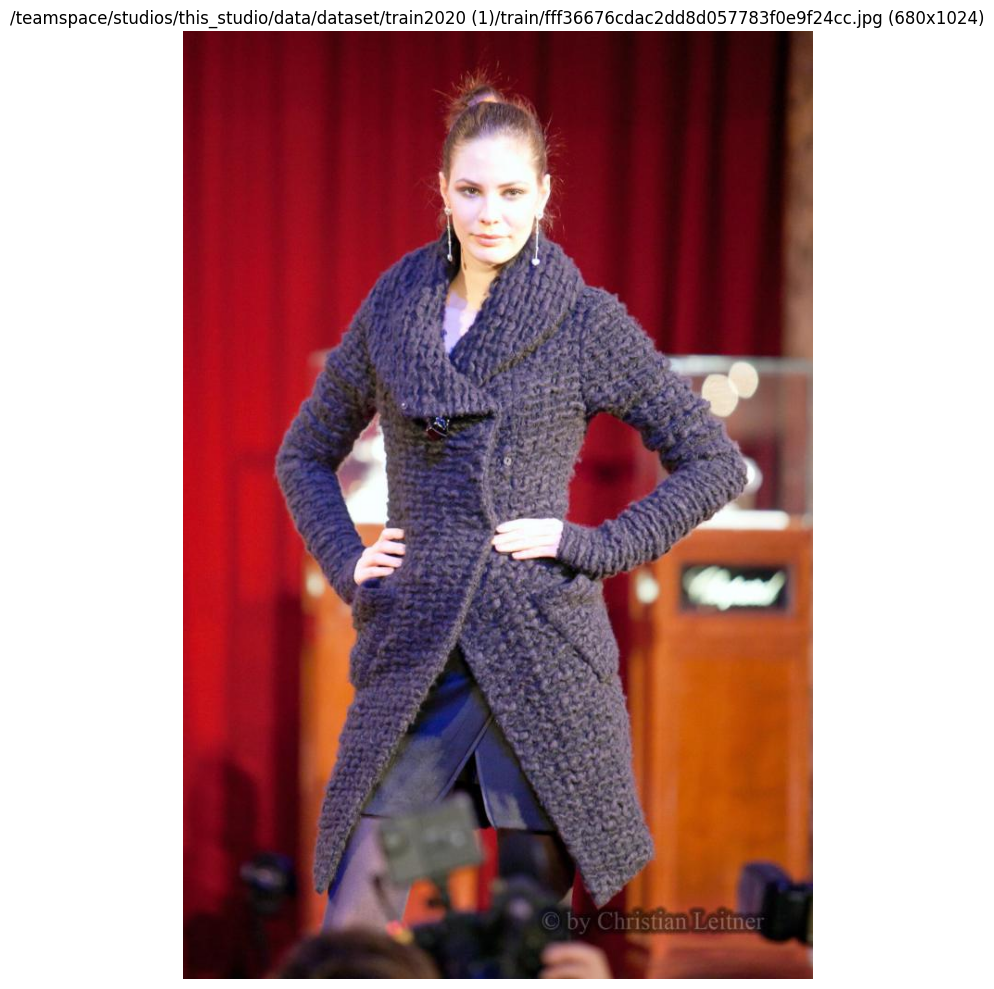


🔄 Processing: "the woolen thing worn"
--------------------------------------------------


NameError: name 'pipeline' is not defined

In [1]:
# ============================================================
# Interactive Demo — Shows image first, then asks for prompt
# ============================================================
import os
import numpy as np
from PIL import Image
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from IPython.display import display, Image as IPImage

print("=" * 60)
image_path = input("📷 Image path: ").strip()

if not os.path.exists(image_path):
    print(f"❌ File not found: {image_path}")
else:
    # Step 1: Show the original image
    print("\n📸 Here is your image:")
    pil_img = Image.open(image_path).convert("RGB")
    fig, ax = plt.subplots(1, 1, figsize=(10, 10))
    ax.imshow(np.array(pil_img))
    ax.set_title(f"{image_path} ({pil_img.size[0]}x{pil_img.size[1]})")
    ax.axis('off'); plt.tight_layout()
    plt.savefig("_preview.png", dpi=100, bbox_inches='tight'); plt.close()
    display(IPImage(filename="_preview.png"))

    # Step 2: Ask for prompt AFTER seeing the image
    prompt = input("\n✏️  Your prompt (e.g. 'Segment the red dress'): ").strip()
    if not prompt:
        print("❌ Empty prompt")
    else:
        # Step 3: Show LLM parsing (how it reconstructs the prompt)
        print(f"\n🔄 Processing: \"{prompt}\"")
        print("-" * 50)

        cats, attrs = pipeline.parser.parse(prompt)

        print(f"\n🧠 LLM Parsing Result:")
        print(f"   Original prompt:  \"{prompt}\"")
        if cats:
            for c in cats:
                print(f"   → Category:       {c['name']} (match: {c['match_type']})")
                print(f"     Alias:          {c['matched_alias']}")
                print(f"     LLM extracted:  \"{c['llm_extracted']}\"")
        print(f"   → Attributes:     {[a['name'] for a in attrs] if attrs else 'none'}")

        grounding_prompts = pipeline.parser.build_grounding_prompts(cats, attrs)
        print(f"\n🔍 Sent to Grounding DINO (synonym-expanded):")
        for gp in grounding_prompts:
            print(f"   → \"{gp}\"")

        # Step 4: Run full pipeline
        save_path = "demo_result.png"
        masks = pipeline.run(
            image_path=image_path,
            user_prompt=prompt,
            box_threshold=0.20, text_threshold=0.15,
            per_category=True, visualize=True, save_path=save_path,
        )

        if masks:
            print(f"\n✅ Found {len(masks)} region(s):")
            for i, m in enumerate(masks):
                print(f"  Region {i+1}: {m['label']} "
                      f"(det={m['det_score']:.3f}, mask={m['mask_score']:.3f})")
                if m.get('visual_attributes'):
                    print(f"    🎨 CLIP Attributes: {m['visual_attributes']}")
                mask_img = Image.fromarray((m['mask'] * 255).astype(np.uint8))
                mask_img.save(f"mask_{i}.png")
                print(f"    💾 Binary mask: mask_{i}.png")
            print(f"\n📸 Result:")
            display(IPImage(filename=save_path))
        else:
            print("❌ No detections. Try different prompt or lower thresholds.")


In [1]:
import transformers
print(transformers.__version__)  # Needs to be >= 4.38.0



4.44.0
